<a href="https://colab.research.google.com/github/ammarnaq/NLP_assignment1/blob/main/NLP_assignment1_noattention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import files

uploaded = files.upload()                          # upload the CSV via Colab dialog
raw_df = pd.read_csv(
    next(iter(uploaded)), encoding="latin-1"
)

print(f"Raw shape : {raw_df.shape}")
print(f"Columns   : {list(raw_df.columns)}")
print(f"\nNull counts:\n{raw_df.isnull().sum()}")
print(f"\nFirst 5 rows:")
raw_df.head()


Saving SPAM text message 20170820 - Data.csv to SPAM text message 20170820 - Data (2).csv
Raw shape : (5572, 2)
Columns   : ['Category', 'Message']

Null counts:
Category    0
Message     0
dtype: int64

First 5 rows:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df = raw_df.copy()

# 1. Drop any columns that are entirely null or irrelevant
null_cols = [col for col in df.columns if df[col].isnull().all()]
if null_cols:
    print(f"Dropping all-null columns: {null_cols}")
    df.drop(columns=null_cols, inplace=True)

# 2. Rename columns to meaningful names
df.rename(columns={"Category": "label", "Message": "text"}, inplace=True)

# 3. Encode text labels → numeric (ham = 0, spam = 1)
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

# 4. Quick sanity checks
print(f"Cleaned shape : {df.shape}")
print(f"\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nEncoded label distribution:")
print(df["label_enc"].value_counts())
print(f"\nSample rows:")
df.head(10)


Cleaned shape : (5572, 3)

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Encoded label distribution:
label_enc
0    4825
1     747
Name: count, dtype: int64

Sample rows:


,label,text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1


In [ ]:
# ── Cell 4: Train/test split & compute text statistics for vectorization ────

# --- Split first so vocab stats come only from training data ---
X = df["text"].values
y = df["label_enc"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Compute statistics from training set ---
word_counts = [len(msg.split()) for msg in X_train]

avg_words_len = int(np.ceil(np.mean(word_counts)))       # average words per SMS → sequence length
total_words_length = len(                                 # unique tokens → vocabulary size
    set(token for msg in X_train for token in msg.split())
)

print("=" * 50)
print("         Dataset & Text Statistics")
print("=" * 50)
print(f"  Total samples        : {len(X)}")
print(f"  Train samples        : {len(X_train)}")
print(f"  Test samples         : {len(X_test)}")
print(f"  Avg words per SMS    : {avg_words_len}")
print(f"  Min words in a SMS   : {min(word_counts)}")
print(f"  Max words in a SMS   : {max(word_counts)}")
print(f"  Unique vocabulary    : {total_words_length}")
print("=" * 50)

         Dataset & Text Statistics
  Total samples        : 5572
  Train samples        : 4457
  Test samples         : 1115
  Avg words per SMS    : 16
  Min words in a SMS   : 1
  Max words in a SMS   : 171
  Unique vocabulary    : 13582


In [ ]:
# ── Cell 5: Helper functions & TextVectorization layer ──────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Helper: compile and fit any model ---
def compile_and_fit(model, X_tr, y_tr, X_val, y_val, epochs=10, batch_size=32):
    """
    Compiles with binary_crossentropy + accuracy, then trains.
    Returns the training History object.
    """
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )
    return history
# --- Helper: compute evaluation metrics ---
def get_metrics(model, X_eval, y_true):
    """
    Predicts on X_eval, rounds probabilities to 0/1,
    and returns accuracy, precision, recall, and F1-score.
    """
    y_prob = model.predict(X_eval, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


# --- Create the TextVectorization layer ---
from tensorflow.keras.layers import TextVectorization

vectorize_layer = TextVectorization(
    max_tokens=total_words_length,       # vocabulary cap from Cell 4
    standardize="lower_and_strip_punctuation",
    output_mode="int",
    output_sequence_length=avg_words_len, # pad / truncate to avg SMS length
)

# Adapt on training data only (learns vocabulary + frequency)
vectorize_layer.adapt(X_train)

print(f"TextVectorization configured:")
print(f"  max_tokens             = {total_words_length}")
print(f"  output_sequence_length = {avg_words_len}")
print(f"  Vocabulary size learnt = {vectorize_layer.vocabulary_size()}")
print(f"\nSample vectorization:")
sample = X_train[:2]
for txt, vec in zip(sample, vectorize_layer(sample).numpy()):
    print(f"  \"{txt[:60]}...\"  →  {vec[:15]}...")



TextVectorization configured:
  max_tokens             = 13582
  output_sequence_length = 16
  Vocabulary size learnt = 8471

Sample vectorization:
  "He will, you guys close?..."  →  [ 75  33   4 310 665   0   0   0   0   0   0   0   0   0   0]...
  "CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER IF URGOIN OUTL..."  →  [  31    3  100   62   42   22 6259 4260   34 4144 5424 5068 8204 6989
 6990]...


In [ ]:
# ── Cell 6: Build & train Bidirectional LSTM model ──────────────────────────
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    GlobalAveragePooling1D, Flatten, Dense, Dropout
)
from tensorflow.keras.models import Model

EMBEDDING_DIM = 128
LSTM_UNITS    = 64

# 1. Input layer — expects raw strings (one SMS per sample)
text_input = Input(shape=(1,), dtype=tf.string, name="raw_text")

# 2. TextVectorization — converts raw text → integer token IDs
x = vectorize_layer(text_input)

# 3. Embedding — learns a dense vector for each token ID
x = Embedding(
    input_dim=total_words_length,      # vocab size from Cell 4
    output_dim=EMBEDDING_DIM,
    input_length=avg_words_len,        # sequence length from Cell 4
    name="embedding",
)(x)

# 4. GlobalAveragePooling1D branch is skipped in favour of the LSTM path,
#    but we note it here: GlobalAveragePooling1D would compress the sequence
#    into a single vector by averaging across time steps. Instead, the two
#    BiLSTM layers below capture richer sequential context.

# 5. Stacked Bidirectional LSTMs
#    First BiLSTM returns full sequences so the second layer can read them.
x = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True), name="bilstm_1"
)(x)

#    Second BiLSTM also returns sequences so we can flatten afterwards.
x = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True), name="bilstm_2"
)(x)

# 6. Flatten the final sequence output into a 1-D vector
x = Flatten(name="flatten")(x)

# 7. Dropout for regularisation
x = Dropout(0.3, name="dropout")(x)

# 8. Dense hidden layer with ReLU activation
x = Dense(64, activation="relu", name="dense_hidden")(x)

# 9. Sigmoid output for binary classification (spam = 1, ham = 0)
output = Dense(1, activation="sigmoid", name="output")(x)

# --- Assemble the model ---
bilstm_model = Model(inputs=text_input, outputs=output, name="BiLSTM_Spam_Classifier")
bilstm_model.summary()

# --- Compile & train using the helper from Cell 5 ---
EPOCHS     = 10
BATCH_SIZE = 32

bilstm_history = compile_and_fit(
    bilstm_model,
    X_train, y_train,
    X_test,  y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

# --- Evaluate on the test set ---
print("\n" + "=" * 50)
print("  Bi-LSTM  —  Test Set Metrics")
print("=" * 50)
bilstm_metrics = get_metrics(bilstm_model, X_test, y_test)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_Spam_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_text (InputLayer)           │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 16)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 16, 128)        │     1,738,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 16, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 16, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,067,329 (7.89 MB)

 Trainable params: 2,067,329 (7.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.9031 - loss: 0.2526 - val_accuracy: 0.9731 - val_loss: 0.0847
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9933 - loss: 0.0283 - val_accuracy: 0.9749 - val_loss: 0.0711
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9975 - loss: 0.0118 - val_accuracy: 0.9785 - val_loss: 0.1036
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9986 - loss: 0.0068 - val_accuracy: 0.9776 - val_loss: 0.1048
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9989 - loss: 0.0029 - val_accuracy: 0.9776 - val_loss: 0.1497
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 1.0000 - loss: 1.1563e-04 - val_accuracy: 0.9758 - val_loss: 0.1742
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 1.0000 - loss: 2.5258e-05 - val_accuracy: 0.9758 - val_loss: 0.1822
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 1.0000 - loss: 1.39

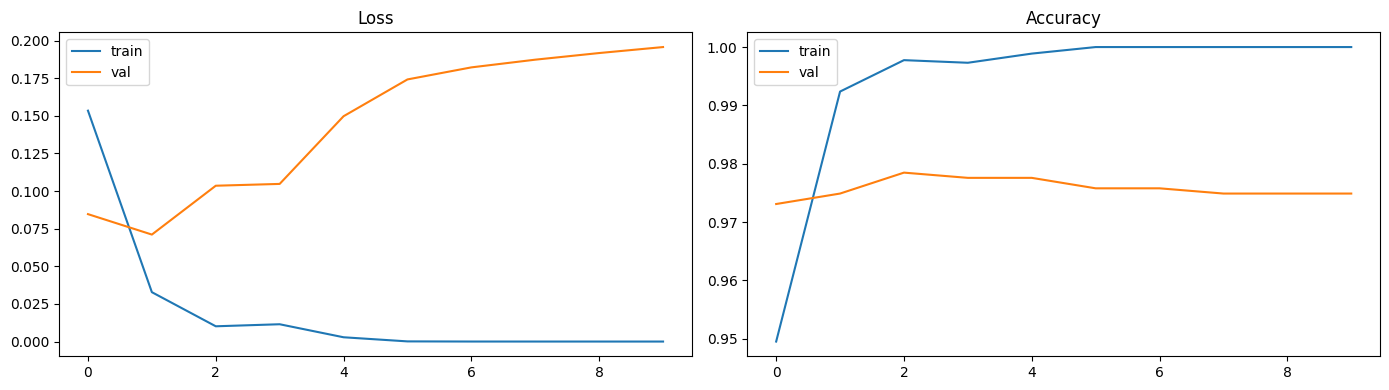

In [ ]:
# ── Cell 7: Training curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(bilstm_history.history["loss"],     label="train")
axes[0].plot(bilstm_history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(bilstm_history.history["accuracy"],     label="train")
axes[1].plot(bilstm_history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.95      0.85      0.90       149

    accuracy                           0.97      1115
   macro avg       0.97      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



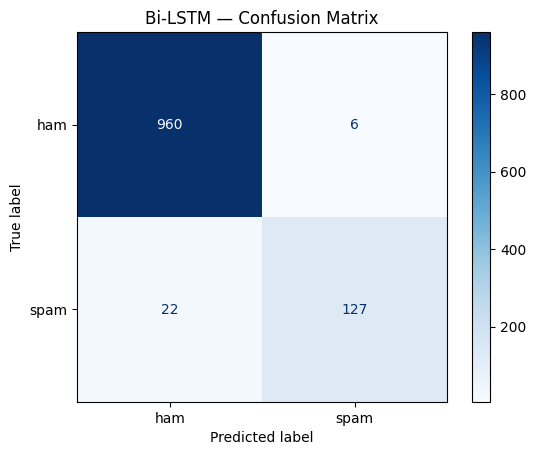

In [ ]:
# ── Cell 8: Evaluate on test set (detailed) ─────────────────────────────────
y_pred_prob = bilstm_model.predict(X_test, verbose=0).ravel()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(cmap="Blues")
plt.title("Bi-LSTM — Confusion Matrix")
plt.show()



In [ ]:
# ── Cell 9: Inference helper ────────────────────────────────────────────────
def predict_message(text: str) -> str:
    prob = bilstm_model.predict(np.array([text]), verbose=0)[0][0]
    label = "spam" if prob >= 0.5 else "ham"
    return f"{label} (confidence: {prob:.4f})"

# Quick sanity check
print(predict_message("You have won a free iPhone! Click here now!"))
print(predict_message("Hey, want to grab coffee after class?"))


ValueError: Invalid dtype: str1376